# XAI-Methoden
In diesem Notebook werden Ansätze vorgestellt, um CNNs interpretierbar zu machen:
gradientenbasierte Methoden (Grad-CAM, Grad-CAM++, XGrad-CAM, LayerCAM) und modellagnostische Methoden (Eigen-CAM, Score-CAM, LIME, SHAP).

### Imports
Das Paket muss mit pip install -e . installiert werden (im Hauptverzeichnis), falls dies noch nicht gemacht wurde. #!pip install -e . kann bei Bedarf auskommentiert werden.

In [1]:
#!pip install -e .
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

from maco_package.quantization import *
from maco_package.utils import *
from maco_package.data import *
from maco_package.visualization import *
from maco_package.xai import *

/home/neli/.local/share/mamba/envs/Master/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ROOT = "../data/imagenet100/versions/8"
train_dataset, val_dataset, class_to_idx = build_datasets(ROOT)
NUM_CLASSES = len(class_to_idx)
synset_to_name = load_class_names(ROOT)

img = show_random_sample(train_dataset, class_to_idx, synset_to_name,return_sample=True)

In Quantize trainierte Modelle ladem:

In [4]:
resnet50_finetuned = load_model(
    path="../saved_models/resnet50_finetuned.pth",
    num_classes=NUM_CLASSES,
    device="cuda"
)
resnet50_qatfake = load_resnet50_qatfake(
    "../saved_models/resnet50_qatfake.pth",
    num_classes=NUM_CLASSES,
    device="cuda"
)
model_int8_qat =  load_resnet50_qat_int8(
    "../saved_models/resnet50_qat_int8.pth",
    num_classes=NUM_CLASSES,
    device="cpu"
)
model_int8_ptq = load_resnet50_ptq_fx_state(
    "../saved_models/resnet50_ptq.pth",
    num_classes=NUM_CLASSES,
    device="cpu"
)

## Gradientenbasierte Methoden
Gradientenbasierte CAM-Methoden benötigen echte, rückpropagierbare Gradienten.
Quantisierte PTQ-Modelle besitzen diese nicht mehr, weil ihre INT8-Operatoren nicht differenzierbar sind. Deshalb lassen sich solche Modelle nicht direkt mit Grad-CAM-Varianten analysieren; untersuchbar ist nur das während des QAT erzeugte Fake-Quant-Modell, da dort die Quantisierung simuliert wird und die FP32-Gradienten erhalten bleiben.

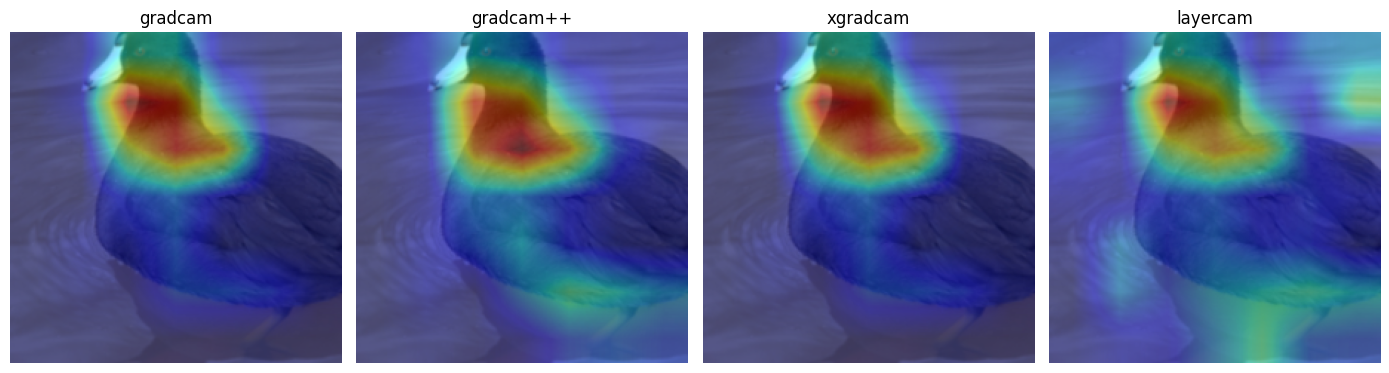

In [57]:
gradcam_maps = compute_gradcams(
    resnet50_finetuned,
    img,
    target_layer="layer4.2",    
    plot=True,
    return_maps=False, 
    device="cuda"
)

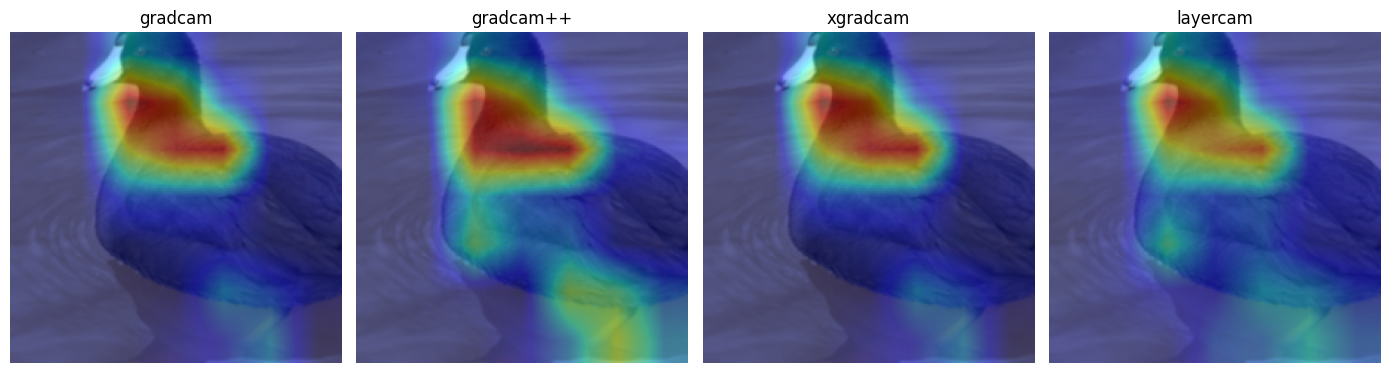

In [59]:
gradcam_maps = compute_gradcams(
    resnet50_qatfake,
    img,
    target_layer="layer4.2",    
    plot=True,
    return_maps=False, 
    device="cuda"
)

## Modellagnostische Methoden
**EigenCAM** benötigt keine Gradienten, da die Aktivierungen selbst per Hauptkomponentenanalyse ausgewertet werden.
Dadurch funktioniert die Methode auch bei quantisierten PTQ-Modellen, weil nur die Forward-Aktivierungen eines Layers gebraucht werden und keine Differenzierbarkeit vorausgesetzt wird.  ( Quantisierte Modelle MÜSSEN auf CPU ausgeführt werden in Pytorch )

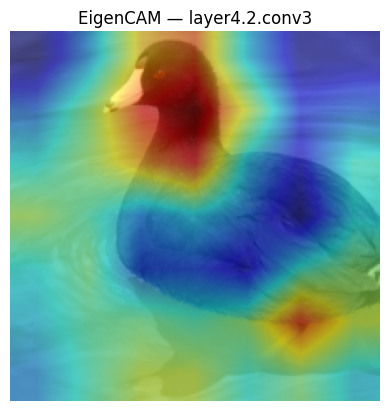

In [48]:
eigencam_map = compute_eigencam(
    resnet50_qatfake,
    img,
    target_layer_name="layer4.2.conv3",
    plot=True,
    return_map=False, 
    device="cuda"
)

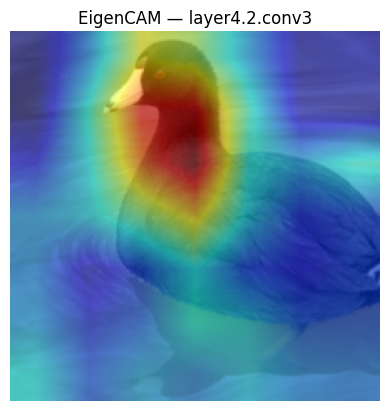

In [62]:

eigencam_map = compute_eigencam(
    model_int8_ptq,
    img,
    target_layer_name="layer4.2.conv3",
    plot=True,
    return_map=False, 
    device="cpu"
)

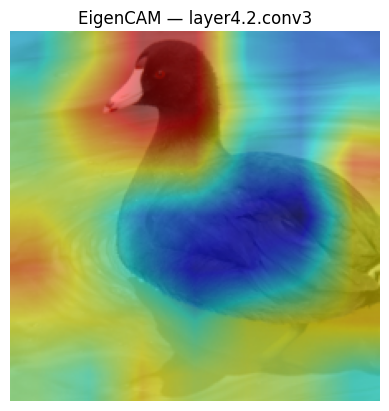

In [47]:
eigencam_map = compute_eigencam(
    model_int8_qat,
    img,
    target_layer_name="layer4.2.conv3",
    plot=True,
    return_map=False, 
    device="cpu"
)

**ScoreCAM** arbeitet auch ohne die Gradienten eines Modells.  
Stattdessen erzeugt die Methode über die Aktivierungen eines Ziel-Layers eine Reihe maskierter Eingaben, für die jeweils ein Score berechnet wird.  
Die Aktivierungskarten dienen als räumliche Masken, deren Einfluss auf den Modelloutput gemessen wird. Die so erhaltenen Scores gewichten die Aktivierungskarten direkt, woraus schließlich die visuelle Erklärung entsteht.

Da ScoreCAM ausschließlich Forward-Pässe nutzt und keine Backpropagation benötigt, funktioniert die Methode auch bei PTQ-quantisierten Modellen. Entscheidend sind nur die Aktivierungen des Layers und der daraus resultierende Output-Score.


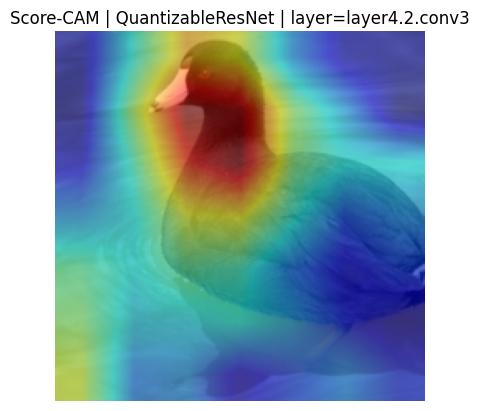

In [63]:
compute_scorecam(
    resnet50_finetuned,
    img,
    target_layer_name="layer4.2.conv3",
    plot=True,
    return_map=False,
    return_overlay=False, 
    device="cuda"
)

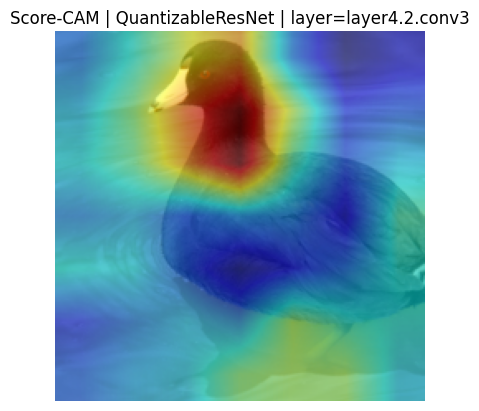

In [50]:
compute_scorecam(
    resnet50_qatfake,
    img,
    target_layer_name="layer4.2.conv3",
    plot=True,
    return_map=False,
    return_overlay=False, 
    device="cuda"
)

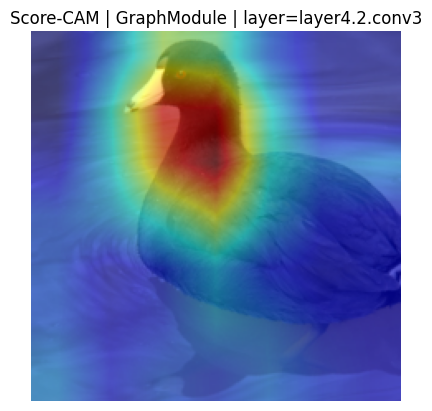

In [51]:

compute_scorecam(
    model_int8_ptq,
    img,
    target_layer_name="layer4.2.conv3",
    plot=True,
    return_map=False,
    return_overlay=False, 
    device="cpu"
)

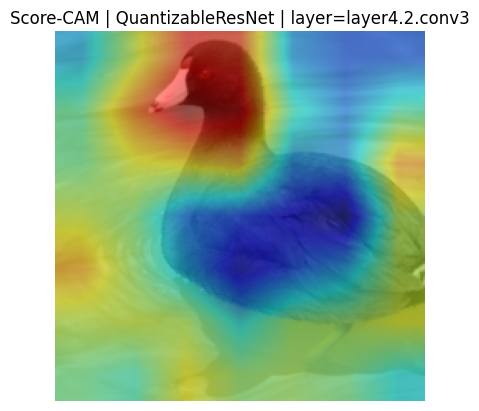

In [52]:
compute_scorecam(
    model_int8_qat,
    img,
    target_layer_name="layer4.2.conv3",
    plot=True,
    return_map=False,
    return_overlay=False, 
    device="cpu"
)

**LIME** erklärt einzelne Vorhersagen durch lokal erzeugte Perturbationen der Eingabe.  
Ein einfaches Ersatzmodell approximiert das Verhalten des Originals; dessen Gewichte zeigen die wichtigsten Features.

100%|██████████████████████████████████████████████████████████████████████| 1000/1000 [00:03<00:00, 290.27it/s]


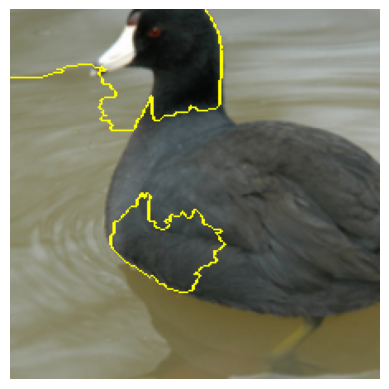

In [32]:
lime_mask = compute_lime(
    resnet50_finetuned,
    img,
    plot=True,
    return_mask=False, 
    device="cuda"
)

100%|███████████████████████████████████████████████████████████████████████| 1000/1000 [00:14<00:00, 69.75it/s]


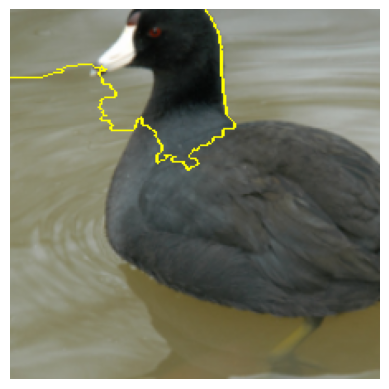

In [14]:
lime_mask = compute_lime(
    model_int8_ptq,
    img,
    plot=True,
    return_mask=False, 
    device="cpu"
)

100%|███████████████████████████████████████████████████████████████████████| 1000/1000 [00:42<00:00, 23.61it/s]


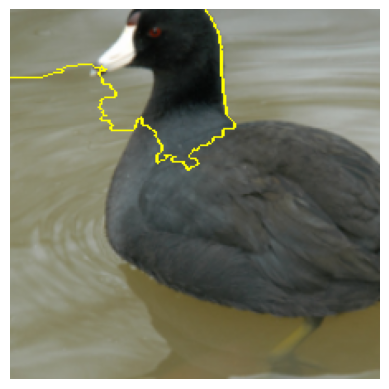

In [15]:
lime_mask = compute_lime(
    resnet50_finetuned,
    img,
    plot=True,
    return_mask=False, 
    device="cpu"
)

**SHAP** ordnet jedem Feature einen quantifizierten Beitrag zur Vorhersage zu.  
Die Methode basiert auf spieltheoretischen Shapley-Werten und liefert additive, modellagnostische Erklärungen.


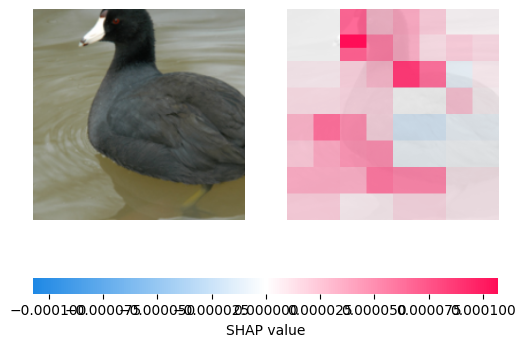

In [16]:
shap_map = compute_shap(
    resnet50_finetuned,
    img,
    plot=True,
    return_values=False, 
    device="cuda"
)

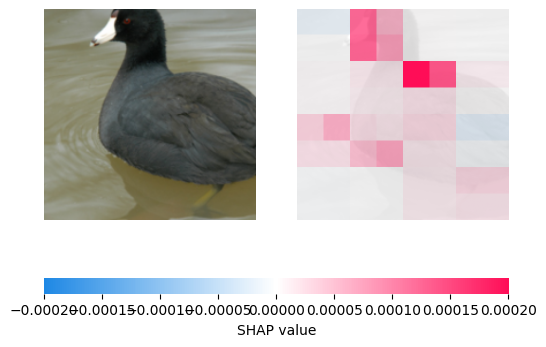

In [17]:
shap_map = compute_shap(
    model_int8_ptq,
    img,
    plot=True,
    return_values=False, 
    device="cpu"
)

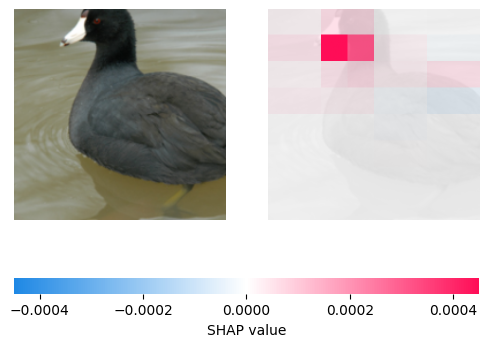

In [18]:
shap_map = compute_shap(
    model_int8_qat,
    img,
    plot=True,
    return_values=False, 
    device="cpu"
)
